In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
import scipy.sparse as sp
from collections import OrderedDict
import seaborn as sns
import scanpy as sc
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))

# Compare CellBender vs. cellsweep

Some datasets of use:
- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k

In [3]:
adata_raw_parent_dir = "/mnt/data1"
adata_filtered_dir = "/mnt/data1/8_cube_cellbender_raw"

verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)

In [4]:
dataset_name = "8cubed"

# create directories for data, output
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

eight_cubed_markers_path = os.path.join(data_dir, "8_cube_marker_genes.csv")
gene_id_name_map_path = os.path.join(data_dir, "gene_id_name_map.csv")

cellsweep_max_iter = 500
cellsweep_beta = 0.1
cellsweep_init_alpha = 0.9

if not os.path.exists(adata_raw_parent_dir):
    raise ValueError(f"adata_raw_parent_dir {adata_raw_parent_dir} does not exist.")
if not os.path.exists(adata_filtered_dir):
    raise ValueError(f"adata_filtered_dir {adata_filtered_dir} does not exist.")

In [5]:
plate_to_tissues = {}
plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]
for plate in plates:
    plate_dir = os.path.join(adata_raw_parent_dir, plate)
    plate_to_tissues[plate] = [tissue for tissue in os.listdir(plate_dir)]
        
plate_to_tissues

{'igvf_003': ['CortexHippocampus', 'Heart'],
 'igvf_004': ['Liver', 'Heart'],
 'igvf_005': ['Liver', 'HypothalamusPituitary'],
 'igvf_007': ['HypothalamusPituitary', 'GonadsFemale', 'GonadsMale'],
 'igvf_008b': ['GonadsFemale', 'GonadsMale', 'Adrenal'],
 'igvf_009': ['Kidney', 'Adrenal'],
 'igvf_010': ['Kidney', 'Gastrocnemius'],
 'igvf_011': ['CortexHippocampus', 'Gastrocnemius']}

## Raw

In [7]:
def load_8cubed_raw_data(adata_dir, backed=None, debug=False):
    # plate: adata
    try:
        from tqdm import tqdm
        tq = tqdm
    except ImportError:
        # no tqdm → identity function
        tq = lambda x, *args, **kwargs: x

    # plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]

    adata_dict = {}
    for plate in tq(plates, desc="Loading AnnData plates"):
        adatas_plate = []
        plate_dir = os.path.join(adata_dir, plate)
        tissues = os.listdir(plate_dir)
        if len(tissues) < 2 or len(tissues) > 3:
            print(f"[WARN] Plate directory {plate_dir} does not contain 2-3 tissues, skipping")
            continue
        for tissue in tissues:
            adata_path = os.path.join(plate_dir, tissue, "adata.h5ad")
            adata = ad.read_h5ad(adata_path, backed=backed)
            if debug:
                adata = adata[:10_000, :].to_memory()
            adata.var_names_make_unique()
            # merge GonadsMale and GonadsFemale into Gonads
            adata.obs["Tissue_original"] = adata.obs["Tissue"]
            adata.obs["Tissue"] = adata.obs["Tissue"].replace({
                "GonadsMale": "Gonads",
                "GonadsFemale": "Gonads",
            })
            adatas_plate.append(adata)
        adata_plate = ad.concat(adatas_plate, axis=0, join="inner", index_unique=None)
        adata_dict[plate] = adata_plate
    return adata_dict

def load_8cubed_filtered_data(adata_dir, debug=False, obs_only=True, tissues_to_include=None):
    # tissue: adata
    try:
        from tqdm import tqdm
        tq = tqdm
    except ImportError:
        # no tqdm → identity function
        tq = lambda x, *args, **kwargs: x

    backed = "r" if obs_only else None

    # List .h5ad files
    files = sorted([os.path.join(adata_dir, f) for f in os.listdir(adata_dir) if f.endswith(".h5ad")])

    if not files:
        raise ValueError(f"No .h5ad files found in: {adata_dir}")

    print(f"Found {len(files)} files:")
    for f in files:
        print("  -", f)

    # Load them
    adata_obs_dict = {}
    for filename in tq(files, desc="Loading AnnData"):
        tissue = os.path.basename(filename).replace("_annotated.h5ad", "")
        if tissues_to_include is not None and tissue not in tissues_to_include:
            print(f"[INFO] Skipping tissue {tissue} not in include list")
            continue
        
        # Load metadata only
        adata = ad.read_h5ad(filename, backed=backed)
        obs = adata.obs.copy()   # copy small metadata only
        if obs_only:
            del adata                # drop the heavy object

        # Debug: limit rows
        if debug:
            obs = obs.iloc[:1_000].copy()

        # Tissue cleanup
        obs["Tissue_original"] = obs["Tissue"]
        obs["Tissue"] = obs["Tissue"].replace({
            "GonadsMale": "Gonads",
            "GonadsFemale": "Gonads",
        })

        # ensure correct index
        if "cellID" in obs.columns:
            obs = obs.set_index("cellID")

        if obs_only:
            adata_obs_dict[tissue] = obs
        else:
            adata.obs = obs
            if "cellbender_counts" in adata.layers:
                adata.X = adata.layers["cellbender_counts"]
            adata_obs_dict[tissue] = adata

    # --- Combine Gonads (obs-only) ---
    if "GonadsMale" in adata_obs_dict and "GonadsFemale" in adata_obs_dict:
        if obs_only:
            adata_obs_dict["Gonads"] = pd.concat(
                [adata_obs_dict["GonadsMale"], adata_obs_dict["GonadsFemale"]],
                axis=0,
                join="inner"
            )
        else:
            adata_obs_dict["Gonads"] = adata_obs_dict["GonadsMale"].concatenate(adata_obs_dict["GonadsFemale"])
        
        del adata_obs_dict["GonadsMale"]
        del adata_obs_dict["GonadsFemale"]

    return adata_obs_dict

def merge_filtered_celltype_and_cluster_into_raw(adata_raw_dict, adata_filtered_tissue_obs_dict):
    adata_raw_plate_with_celltype_dict = {}

    for plate, adata in adata_raw_dict.items():
        if "celltype" in adata.obs.columns:
            print(f"[WARN] Plate {plate} already has celltype column — skipping")
            adata_raw_plate_with_celltype_dict[plate] = adata
            continue

        # Make a copy so original isn't modified
        # adata = adata.copy()

        # Start by initializing the column with Empty Droplet everywhere
        adata.obs["celltype"] = "Empty Droplet"
        adata.obs["leiden"] = "unassigned"

        # Loop over tissues for this plate
        for tissue in adata.obs["Tissue"].unique():

            if tissue not in adata_filtered_tissue_obs_dict:
                print(f"[WARN] Tissue {tissue} not in filtered dict — skipping")
                continue

            adata_obs_filtered = adata_filtered_tissue_obs_dict[tissue]

            cols_to_merge = ["celltype", "leiden"]
            missing = [c for c in cols_to_merge if c not in adata_obs_filtered.columns]
            if missing:
                print(f"[WARN] Filtered {tissue} missing columns {missing} — skipping")
                continue

            # Filtered celltypes index
            filt_obs = adata_obs_filtered[cols_to_merge].copy()

            # Only cells that exist in this raw plate
            common_idx = adata.obs.index.intersection(filt_obs.index)

            if len(common_idx) == 0:
                print(f"[INFO] No shared cells between plate {plate} and {tissue}")
                continue

            # Insert celltypes for those cells
            adata.obs.loc[common_idx, cols_to_merge] = filt_obs.loc[common_idx, cols_to_merge]

        # Store final annotated plate
        adata_raw_plate_with_celltype_dict[plate] = adata

    return adata_raw_plate_with_celltype_dict

In [7]:
adata_raw_dict = load_8cubed_raw_data(adata_raw_parent_dir)
adata_filtered_tissue_obs_dict = load_8cubed_filtered_data(adata_filtered_dir, obs_only=True)

Loading AnnData plates:   0%|          | 0/5 [00:00<?, ?it/s]/tmp/ipykernel_3803721/2737183695.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["Tissue"] = adata.obs["Tissue"].replace({
/tmp/ipykernel_3803721/2737183695.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["Tissue"] = adata.obs["Tissue"].replace({
Loading AnnData plates:  20%|██        | 1/5 [01:47<07:11, 107.98s/it]/tmp/ipykernel_3803721/2737183695.py:28: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future v

Found 9 files:
  - /mnt/data1/8_cube_cellbender_raw/Adrenal_annotated.h5ad
  - /mnt/data1/8_cube_cellbender_raw/CortexHippocampus_annotated.h5ad
  - /mnt/data1/8_cube_cellbender_raw/Gastrocnemius_annotated.h5ad
  - /mnt/data1/8_cube_cellbender_raw/GonadsFemale_annotated.h5ad
  - /mnt/data1/8_cube_cellbender_raw/GonadsMale_annotated.h5ad
  - /mnt/data1/8_cube_cellbender_raw/Heart_annotated.h5ad
  - /mnt/data1/8_cube_cellbender_raw/HypothalamusPituitary_annotated.h5ad
  - /mnt/data1/8_cube_cellbender_raw/Kidney_annotated.h5ad
  - /mnt/data1/8_cube_cellbender_raw/Liver_annotated.h5ad


Loading AnnData:  33%|███▎      | 3/9 [09:12<17:29, 174.86s/it]/tmp/ipykernel_3803721/2737183695.py:75: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  obs["Tissue"] = obs["Tissue"].replace({
Loading AnnData:  44%|████▍     | 4/9 [10:50<12:01, 144.38s/it]/tmp/ipykernel_3803721/2737183695.py:75: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  obs["Tissue"] = obs["Tissue"].replace({
Loading AnnData: 100%|██████████| 9/9 [25:33<00:00, 170.37s/it]


## Knee plot - use this output to estimate umi_cutoff

In [8]:
expected_cells = {plate: 0 for plate in adata_raw_dict.keys()}
for adata_obs in adata_filtered_tissue_obs_dict.values():
    for plate in adata_obs["plate"].unique():
        if plate in expected_cells:
            # sum value counts from adata
            expected_cells[plate] += int((adata_obs["plate"] == plate).sum())
expected_cells

{'igvf_007': 879650,
 'igvf_008b': 606911,
 'igvf_009': 772261,
 'igvf_010': 844946,
 'igvf_011': 806290}

Processing plate igvf_007 for knee plot with expected cells = 879650
UMI cutoff for expected cells (879650): 988.00
Processing plate igvf_008b for knee plot with expected cells = 606911
UMI cutoff for expected cells (606911): 500.00
Processing plate igvf_009 for knee plot with expected cells = 772261
UMI cutoff for expected cells (772261): 805.00
Processing plate igvf_010 for knee plot with expected cells = 844946
UMI cutoff for expected cells (844946): 729.00
Processing plate igvf_011 for knee plot with expected cells = 806290
UMI cutoff for expected cells (806290): 721.00


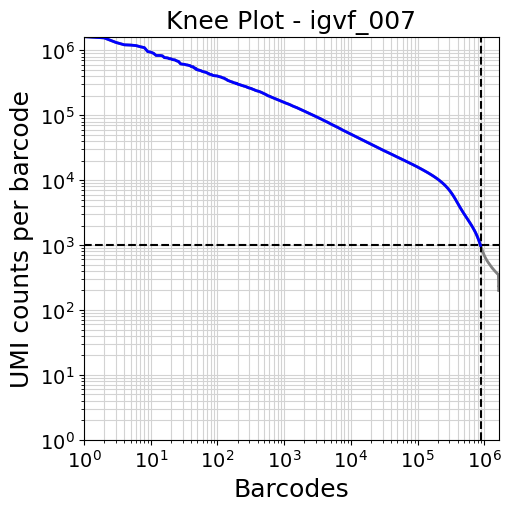

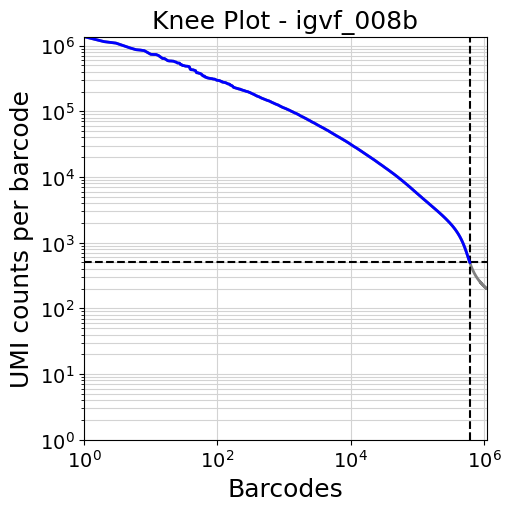

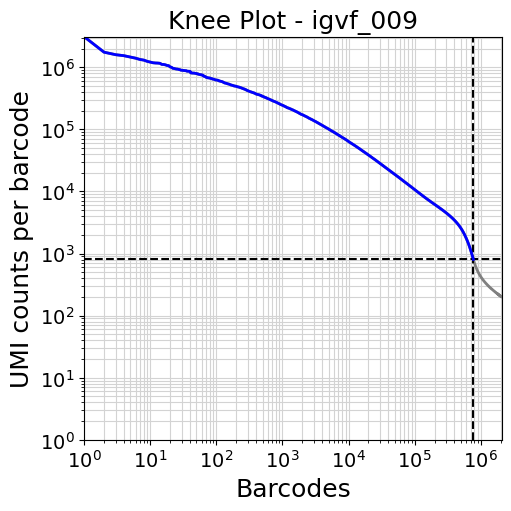

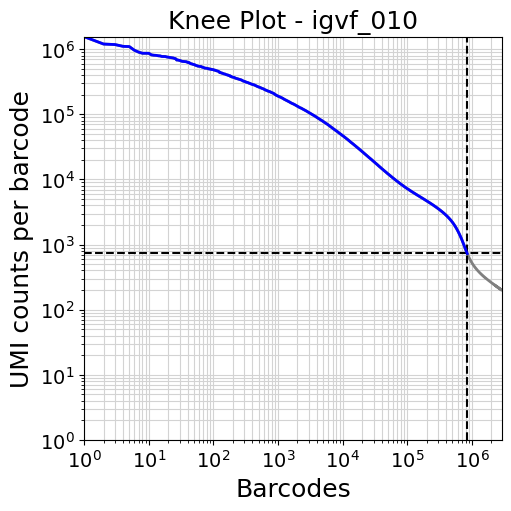

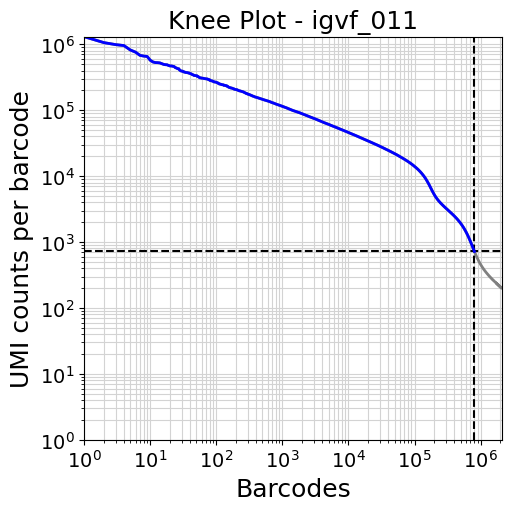

In [9]:
umi_cutoffs = {}
for plate, adata_raw in adata_raw_dict.items():
    print(f"Processing plate {plate} for knee plot with expected cells = {expected_cells[plate]}")
    umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=expected_cells[plate], title=f"Knee Plot - {plate}", out_path=os.path.join(out_dir, f"plate_{plate}", f"knee_plot_{plate}.png"))
    umi_cutoffs[plate] = umi_cutoff

In [17]:
#!!! optionally update umi_cutoffs from knee plot - required for None values
# umi_cutoffs = {
#     "igvf_003": None,
#     "igvf_004": None,
#     "igvf_005": None,
#     "igvf_007": None,
#     "igvf_008b": None,
#     "igvf_009": None,
#     "igvf_010": None,
#     "igvf_011": None,
# }

In [10]:
adata_raw_dict = merge_filtered_celltype_and_cluster_into_raw(adata_raw_dict, adata_filtered_tissue_obs_dict)

[INFO] No shared cells between plate igvf_007 and HypothalamusPituitary
[INFO] No shared cells between plate igvf_007 and Gonads
[INFO] No shared cells between plate igvf_008b and Gonads
[INFO] No shared cells between plate igvf_008b and Adrenal
[INFO] No shared cells between plate igvf_009 and Kidney
[INFO] No shared cells between plate igvf_009 and Adrenal
[INFO] No shared cells between plate igvf_010 and Kidney
[INFO] No shared cells between plate igvf_010 and Gastrocnemius
[INFO] No shared cells between plate igvf_011 and CortexHippocampus
[INFO] No shared cells between plate igvf_011 and Gastrocnemius


## Organize cellbender adatas

In [ ]:
tissues_to_include = ["GonadsMale", "GonadsFemale", "Adrenal", "Kidney", "Gastrocnemius"]  #!!! tissues_to_include = None  # ["Gastrocnemius", "CortexHippocampus", "Heart", "Liver", "HypothalamusPituitary"]  # ["GonadsMale", "GonadsFemale", "Adrenal", "Kidney", "Gastrocnemius"]
adata_filtered_tissue_dict = load_8cubed_filtered_data(adata_filtered_dir, obs_only=False, tissues_to_include=tissues_to_include)
adata_cellbender_dict = {}
for tissue in adata_filtered_tissue_dict:
    print(f"Processing CellBender data from tissue {tissue}...")
    if adata_filtered_tissue_dict[tissue].var.index.name == "gene_id":  # make sure gene_name is index, gene_id is a column
        adata_filtered_tissue_dict[tissue].var["gene_id"] = adata_filtered_tissue_dict[tissue].var.index
        adata_filtered_tissue_dict[tissue].var = adata_filtered_tissue_dict[tissue].var.set_index("gene_name")
    # Map predicted_doublet to boolean (had some "True"/"False" strings)
    adata_filtered_tissue_dict[tissue].obs["predicted_doublet"] = adata_filtered_tissue_dict[tissue].obs["predicted_doublet"].fillna(False).astype(str).map({"True": True, "False": False})
    for plate in adata_filtered_tissue_dict[tissue].obs["plate"].unique().tolist():
        if plate not in plates:
            continue
        if plate not in adata_cellbender_dict:
            adata_cellbender_dict[plate] = adata_filtered_tissue_dict[tissue][adata_filtered_tissue_dict[tissue].obs["plate"] == plate].copy()
        else:
            adata_cellbender_dict[plate] = adata_cellbender_dict[plate].concatenate(adata_filtered_tissue_dict[tissue][adata_filtered_tissue_dict[tissue].obs["plate"] == plate])

In [38]:
#!!! erase below
for plate, adata in adata_cellbender_dict.items():
    adata_path = os.path.join(data_dir, plate, "cellbender.h5ad")
    if not os.path.exists(adata_path):
        os.makedirs(os.path.dirname(adata_path), exist_ok=True)
        adata.write_h5ad(adata_path)
    if not os.path.exists(gene_id_name_map_path):
        # gene_name is in adata.var and doesn't start with ENSMUSG, and gene_id is in adata.var and starts with ENSMUSG
        if adata.var.index.name == "gene_id":
            adata.var["gene_id"] = adata.var.index
        if adata.var.index.name == "gene_name":
            adata.var["gene_name"] = adata.var.index
        if "gene_name" not in adata.var.columns or "gene_id" not in adata.var.columns or adata.var["gene_name"].str.startswith("ENSMUSG").all() or not adata.var["gene_id"].str.startswith("ENSMUSG").all():
            continue
        # no duplicates AND default index
        gene_map_df = pd.DataFrame({
            "gene_id": adata.var["gene_id"],
            "gene_name": adata.var["gene_name"]
        }).drop_duplicates().reset_index(drop=True)
        gene_map_df.to_csv(gene_id_name_map_path, index=False)

## Merge cellbender clusters into raw adatas

In [21]:
for plate in adata_raw_dict.keys():
    adata_raw = adata_raw_dict[plate]
    if "leiden" in adata_raw.obs.columns:
        print(f"[WARN] Plate {plate} already has leiden column — skipping")
        continue
    adata_cb = adata_cellbender_dict[plate]

    adata_raw.obs = adata_raw.obs.join(
        adata_cb.obs[["leiden"]],
        how="left",
        rsuffix="_cellbender",
    )

    adata_raw_dict[plate] = adata_raw

[WARN] Plate igvf_003 already has leiden column — skipping
[WARN] Plate igvf_004 already has leiden column — skipping
[WARN] Plate igvf_005 already has leiden column — skipping


## Identify and filter empty droplets

In [11]:
adata_raw_filtered_dict = {}
for plate, adata_raw in adata_raw_dict.items():
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoffs[plate], verbose=verbose)  # adds adata.obs["is_empty"]
    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()
    adata_raw_dict[plate] = adata_raw
    adata_raw_filtered = adata_raw[~adata_raw.obs["is_empty"]].copy()
    adata_raw_filtered_dict[plate] = adata_raw_filtered

In [12]:
for plate in adata_raw_dict.keys():
    total_counts = adata_raw_dict[plate].X.sum()
    print(f"Total barcodes (cells + empty) in plate {plate}: {adata_raw_dict[plate].n_obs}, total expected cells: {expected_cells[plate]}, total genes: {adata_raw_dict[plate].n_vars}, total counts: {total_counts}")

Total barcodes (cells + empty) in plate igvf_007: 1646368, total expected cells: 879650, total genes: 56953, total counts: 7321078784.0
Total barcodes (cells + empty) in plate igvf_008b: 1083735, total expected cells: 606911, total genes: 56953, total counts: 2822093568.0
Total barcodes (cells + empty) in plate igvf_009: 2070467, total expected cells: 772261, total genes: 56953, total counts: 6224327680.0
Total barcodes (cells + empty) in plate igvf_010: 2882612, total expected cells: 844946, total genes: 56953, total counts: 5048201216.0
Total barcodes (cells + empty) in plate igvf_011: 2084836, total expected cells: 806290, total genes: 56953, total counts: 5433896960.0


In [26]:
adata_raw_dict

{'igvf_003': AnnData object with n_obs × n_vars = 1787176 × 56953
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool', 'bc1_well', 'bc2_well', 'bc3_well', 'Mouse_Tissue_ID', 'alias_tissue1', 'alias_tissue2', 'alias_tissue3', 'alias_tissue4', 'plate', 'Protocol', 'Chemistry', 'well_type', 'Row', 'Column', 'Genotype', 'Notes', 'Multiplexed_sample1', 'Multiplexed_sample2', 'SampleType', 'Tissue', 'Tissue_ID', 'Tissue1_ontology_id', 'Tissue2_ontology_id', 'Sex', 'Replicate', 'DOB', 'Age_weeks', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'Dissector', 'Tissue_weight_mg', 'mult_genotype_1', 'mult_genotype_2', 'mult_genotype', 'n_counts', 'B6J', 'NODJ', '129S1J', 'CASTJ', 'AJ', 'PWKJ', 'WSBJ', 'NZOJ', 'doublet_scores', 'batch', 'Tissue_original', 'celltype', 'leiden', 'is_empty'
     var: 'empty_counts',
 'igvf_004': AnnData object with n_obs × n_vars = 3001436 × 56953
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 

In [27]:
adata_raw_filtered_dict

{'igvf_003': AnnData object with n_obs × n_vars = 643324 × 56953
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'subpool', 'bc1_well', 'bc2_well', 'bc3_well', 'Mouse_Tissue_ID', 'alias_tissue1', 'alias_tissue2', 'alias_tissue3', 'alias_tissue4', 'plate', 'Protocol', 'Chemistry', 'well_type', 'Row', 'Column', 'Genotype', 'Notes', 'Multiplexed_sample1', 'Multiplexed_sample2', 'SampleType', 'Tissue', 'Tissue_ID', 'Tissue1_ontology_id', 'Tissue2_ontology_id', 'Sex', 'Replicate', 'DOB', 'Age_weeks', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'Dissector', 'Tissue_weight_mg', 'mult_genotype_1', 'mult_genotype_2', 'mult_genotype', 'n_counts', 'B6J', 'NODJ', '129S1J', 'CASTJ', 'AJ', 'PWKJ', 'WSBJ', 'NZOJ', 'doublet_scores', 'batch', 'Tissue_original', 'celltype', 'leiden', 'is_empty'
     var: 'empty_counts',
 'igvf_004': AnnData object with n_obs × n_vars = 679841 × 56953
     obs: 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 's

## Save Anndatas

In [ ]:
for plate, adata in adata_raw_dict.items():
    adata_path = os.path.join(data_dir, plate, "raw_counts.h5ad")
    if not os.path.exists(adata_path):
        os.makedirs(os.path.dirname(adata_path), exist_ok=True)
        adata.write_h5ad(adata_path)

for plate, adata in adata_raw_filtered_dict.items():
    adata_path = os.path.join(data_dir, plate, "raw_counts_removed_empty_barcodes.h5ad")
    if not os.path.exists(adata_path):
        os.makedirs(os.path.dirname(adata_path), exist_ok=True)
        adata.write_h5ad(adata_path)

for plate, adata in adata_cellbender_dict.items():
    adata_path = os.path.join(data_dir, plate, "cellbender.h5ad")
    if not os.path.exists(adata_path):
        os.makedirs(os.path.dirname(adata_path), exist_ok=True)
        adata.write_h5ad(adata_path)
    if not os.path.exists(gene_id_name_map_path):
        # gene_name is in adata.var and doesn't start with ENSMUSG, and gene_id is in adata.var and starts with ENSMUSG
        if adata.var.index.name == "gene_id":
            adata.var["gene_id"] = adata.var.index
        if adata.var.index.name == "gene_name":
            adata.var["gene_name"] = adata.var.index
        if "gene_name" not in adata.var.columns or "gene_id" not in adata.var.columns or adata.var["gene_name"].str.startswith("ENSMUSG").all() or not adata.var["gene_id"].str.startswith("ENSMUSG").all():
            continue
        # no duplicates AND default index
        gene_map_df = pd.DataFrame({
            "gene_id": adata.var["gene_id"],
            "gene_name": adata.var["gene_name"]
        }).drop_duplicates().reset_index(drop=True)
        gene_map_df.loc[len(gene_map_df)] = ["ENSMUSG00000051747.17", "Ttn"]  # add missing Ttn gene
        gene_map_df.to_csv(gene_id_name_map_path, index=False)

NameError: name 'adata_cellbender_dict' is not defined

## Markers

In [29]:
if not os.path.exists(eight_cubed_markers_path):
    eight_cubed_markers_url = "https://docs.google.com/spreadsheets/d/1RJHnxeobFfXAQdrUGAn4SWxQZzs0KaheuLJgNc6AjCg/export?format=csv&gid=0"
    r = requests.get(eight_cubed_markers_url)
    with open(eight_cubed_markers_path, "wb") as f:
        f.write(r.content)

eight_cubed_markers_df = pd.read_csv(eight_cubed_markers_path)
if "gene_id" not in eight_cubed_markers_df.columns:
    # make gene_name_to_symbol_df
    files = sorted([os.path.join(adata_filtered_dir, f) for f in os.listdir(adata_filtered_dir) if f.endswith(".h5ad")])
    first_file = files[0]
    adata_tmp = ad.read_h5ad(first_file, backed="r")
    gene_name_to_symbol_df = adata_tmp.var[["gene_name", "gene_id"]].copy()
    gene_name_to_symbol_df = gene_name_to_symbol_df.reset_index(drop=True)
    eight_cubed_markers_df = eight_cubed_markers_df.merge(gene_name_to_symbol_df, left_on="ai", right_on="gene_name", how="left")
    eight_cubed_markers_df.to_csv(eight_cubed_markers_path, index=False)

## cellsweep

### Run this or scripts/run_8cube.py

In [ ]:
max_ram_gb = 500  # 300 GB

# Set max RAM usage in bytes
if max_ram_gb is None:
    max_ram_gb = 16

MAX_RAM = max_ram_gb * 1024**3

# plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]
# adata_raw_dict = {}
# for plate in plates:
#     adata_raw_dict[plate] = ad.read_h5ad(os.path.join(data_dir, plate, "raw_counts.h5ad"))

expected_cells = {
    'igvf_003': 639885,
    'igvf_004': 745458,
    'igvf_005': 694748,
    'igvf_007': 786528,
    'igvf_008b': 504134,
    'igvf_009': 641097,
    'igvf_010': 659512,
    'igvf_011': 721541
}

adata_cellsweep_dict = {}
# for plate, adata_raw in adata_raw_dict.items():
try:
    for plate in plates:
        adata_path_cellsweep = os.path.join(data_dir, plate, "cellsweep.h5ad")
        if os.path.exists(adata_path_cellsweep) and not overwrite:
            print(f"Cellsweep output for plate {plate} already exists at {adata_path_cellsweep}, skipping...")
            continue
        print(f"Processing Cellsweep for plate {plate}...")
        adata_raw = ad.read_h5ad(os.path.join(data_dir, plate, "raw_counts.h5ad"))
        cellsweep_log_path = os.path.join(data_dir, plate, "cellsweep.log")
        
        adata_cellsweep = denoise_count_matrix(adata_raw, adata_out=adata_path_cellsweep, beta=cellsweep_beta, freeze_ambient_profile=True, init_alpha=cellsweep_init_alpha, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells[plate], threads=threads, verbose=verbose, log_file=cellsweep_log_path)
        # adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
        # adata_cellsweep.var_names_make_unique()
        # adata_filtered_path_cellsweep = os.path.join(data_dir, plate, "cellsweep_filtered.h5ad")
        # if not os.path.exists(adata_filtered_path_cellsweep) or overwrite:
        #     adata_cellsweep.write_h5ad(adata_filtered_path_cellsweep)
        # adata_cellsweep_dict[plate] = adata_cellsweep

        adata_cellsweep = None  #? memory management
        del adata_raw   #? memory management
except MemoryError:
    print("❌ Memory limit exceeded — exiting")  # might just print 'Segmentation fault (core dumped)' rather than this
    sys.exit(1)

# for plate, adata in adata_cellsweep_dict.items():
#     adata_path = os.path.join(data_dir, plate, "cellsweep.h5ad")
#     if not os.path.exists(adata_path):
#         os.makedirs(os.path.dirname(adata_path), exist_ok=True)
#         adata.write_h5ad(adata_path)

# Analysis

In [ ]:
for plate in adata_raw_dict.keys():
    print(f"Plate: {plate}")
    # print(f"Adata raw (all barcodes): {adata_raw_dict[plate]}")
    # print(f"Adata raw (filtered barcodes): {adata_raw_filtered_dict[plate]}")
    print(f"Adata cellsweep: {adata_cellsweep_dict[plate]}\n\n")

## 8 Cubed Analysis

### Run this or scripts/visualize_8cube.py

In [ ]:
import os
import anndata as ad
import pandas as pd
import numpy as np
import itertools
import resource
import sys
import cellsweep.utils as cs_utils

debug = False
plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]  # ["igvf_003"]  #? debug
include_cellbender = False
print_custom_markers = True
overwrite = False
max_ram_gb = 600  # GB
custom_markers = {
    'CortexHippocampus': ["Snap25", "Nrxn3", "Nrxn1"],  # Snap25: found in plate 3, tissue heart, cluster 36; Nrxn3, Nrxn1: found in plate 11, tissue gastroc, cluster 38
    'Heart': [],
    'Liver': ["Alb"],  # found in plate 5, tissue heart, cluster 30
    'HypothalamusPituitary': [],
    'Gonads': [],
    'Adrenal': ["Star"],  # found in plate 9, tissue kidney, cluster 14
    'Kidney': ["Slc34a1"],  # found in plate 10, tissue gastroc, cluster 32
    'Gastrocnemius': ["Myh4"]  # found in plate 10, tissue kidney, clusters 0,28,29,30
}
# custom_markers = {
#     'CortexHippocampus': ["Nrxn3", "Nrxn1", "Meis2", "Slc17a7", "Mir124a-1hg", "Snap25"],
#     'Heart': [],
#     'Liver': ["Cyp1a2", "Ttr", "Alb"],
#     'HypothalamusPituitary': [],
#     'Gonads': [],
#     'Adrenal': ["Chga", "Star"],
#     'Kidney': ["Slc5a2", "Slc34a1", "Akr1c21"],
#     'Gastrocnemius': ["Myh4", "Myh2", "Myh1"]
# }

# cellsweep_dir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
# data_dir = os.path.join(cellsweep_dir, "notebooks", "data2", "8cubed")
# eight_cubed_markers_path = os.path.join(data_dir, "8_cube_marker_genes.csv")
# gene_id_name_map_path = os.path.join(data_dir, "gene_id_name_map.csv")
# out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "8cubed")
# os.makedirs(out_dir, exist_ok=True)

# Set max RAM usage in bytes
if max_ram_gb is None:
    max_ram_gb = 16

MAX_RAM = max_ram_gb * 1024**3

soft, hard = resource.getrlimit(resource.RLIMIT_AS)
resource.setrlimit(resource.RLIMIT_AS, (MAX_RAM, MAX_RAM))

all_custom_markers_start_with_ensmug = all(gene.startswith("ENSMUG") for genes in custom_markers.values() for gene in genes)
gene_name_to_id = None

try:
    adata_raw_filtered_dict, adata_cellsweep_dict, adata_cellbender_dict = {}, {}, {}
    for plate in plates:
        print(f"Loading data for plate {plate}...")
        adata_raw_filtered_path = os.path.join(data_dir, plate, "raw_counts_removed_empty_barcodes.h5ad")
        if not os.path.exists(adata_raw_filtered_path):
            print(f"  File {adata_raw_filtered_path} does not exist, skipping...")
            continue
        adata_raw_filtered = ad.read_h5ad(adata_raw_filtered_path)
        adata_raw_filtered.var_names_make_unique()
        if debug:  # filter to 5000 cells for debugging
            np.random.seed(42)
            adata_raw_filtered = adata_raw_filtered[np.random.choice(adata_raw_filtered.n_obs, size=5000, replace=False), :].copy()
            barcodes = adata_raw_filtered.obs_names
        adata_raw_filtered_dict[plate] = adata_raw_filtered
        adata_raw_filtered = None  # free memory

        adata_cellsweep_path = os.path.join(data_dir, plate, "cellsweep.h5ad")
        if not os.path.exists(adata_cellsweep_path):
            print(f"  File {adata_cellsweep_path} does not exist, skipping...")
            continue
        adata_cellsweep = ad.read_h5ad(adata_cellsweep_path)
        adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
        adata_cellsweep.var_names_make_unique()
        if debug:  # filter to the same 5000 cells as above for debugging
            adata_cellsweep = adata_cellsweep[adata_cellsweep.obs_names.isin(barcodes), :].copy()
        adata_cellsweep_dict[plate] = adata_cellsweep
        adata_cellsweep = None  # free memory

        if not include_cellbender and all_custom_markers_start_with_ensmug:
            continue
        
        adata_cellbender_path = os.path.join(data_dir, plate, "cellbender.h5ad")
        if not os.path.exists(adata_cellbender_path):
            print(f"  File {adata_cellbender_path} does not exist, skipping...")
            continue
        adata_cellbender = ad.read_h5ad(adata_cellbender_path)
        
        if custom_markers is not None and len(custom_markers) > 0 and gene_name_to_id is None:
            if "gene_name" not in adata_cellbender.var.columns or "gene_id" not in adata_cellbender.var.columns or adata_cellbender.var["gene_name"].str.startswith("ENSMUSG").all() or not adata_cellbender.var["gene_id"].str.startswith("ENSMUSG").all():
                gene_name_to_id = pd.read_csv(gene_id_name_map_path).set_index("gene_name")["gene_id"].to_dict()
            else:    
                gene_name_to_id = adata_cellbender.var.set_index("gene_name")["gene_id"].to_dict()
        
        if not all_custom_markers_start_with_ensmug:
            for tissue in custom_markers:
                gene_ids = []
                for gene_name in custom_markers[tissue]:
                    gene_id = gene_name_to_id.get(gene_name)
                    if gene_id is not None:
                        gene_ids.append(gene_id)
                custom_markers[tissue] = gene_ids
            all_custom_markers_start_with_ensmug = True
        if not include_cellbender:
            adata_cellbender = None  # free memory
            continue

        if adata_cellbender.obs_names[0].endswith("-0") or adata_cellbender.obs_names[0].endswith("-1"):  # strip "-0/-1" suffix from barcodes added by CellBender
            adata_cellbender.obs_names = [bc[:-2] for bc in adata_cellbender.obs_names]
        if not adata_cellbender.var_names[0].startswith("ENSMUSG"):
            adata_cellbender.var_names = adata_cellbender.var["gene_id"].astype(str)  # Assign gene_id as the new index
        adata_cellbender.var_names_make_unique()
        if debug:  # filter to the same 5000 cells as above for debugging
            adata_cellbender = adata_cellbender[adata_cellbender.obs_names.isin(barcodes), :].copy()
        adata_cellbender_dict[plate] = adata_cellbender
        adata_cellbender = None  # free memory
    
    if custom_markers is not None and len(custom_markers) > 0 and not all_custom_markers_start_with_ensmug:
        raise ValueError("Custom markers contain gene names that were not found in CellBender data; cannot proceed.")

    # np.random.seed(42)
    # adata_cellsweep_dict["igvf_003"] = adata_cellsweep_dict["igvf_003"][np.random.choice(adata_cellsweep_dict["igvf_003"].n_obs, size=5000, replace=False), :].copy()  #? debug

    dict_of_adata_dicts = {
        "raw": adata_raw_filtered_dict,
        "cellsweep": adata_cellsweep_dict,
        "cellbender": adata_cellbender_dict,
    }
    if not include_cellbender:
        dict_of_adata_dicts.pop("cellbender")
    print("Generating 8cubed plots...")
    cs_utils.make_8cubed_plots(dict_of_adata_dicts, eight_cubed_markers_path, custom_markers=custom_markers, gene_name_to_id=gene_name_to_id, print_custom_markers=print_custom_markers, out_dir=out_dir, overwrite=overwrite)
except MemoryError:
    print("❌ Memory limit exceeded — exiting")  # might just print 'Segmentation fault (core dumped)' rather than this
    sys.exit(1)


Plate igvf_003
                Tissue      gene_name                gene_id   ambient_hat  ambient_rank
226              Heart            Ttn  ENSMUSG00000051747.16  1.229538e-02             5
212              Heart           Myh6  ENSMUSG00000040752.17  3.334800e-03            18
261              Heart          Cadm2  ENSMUSG00000064115.14  2.597234e-03            23
221              Heart           Ryr2  ENSMUSG00000021313.17  1.621088e-03            42
5    CortexHippocampus         Slc1a2  ENSMUSG00000005089.16  1.456247e-03            51
166  CortexHippocampus         Camk2a  ENSMUSG00000024617.17  9.512655e-04            95
167  CortexHippocampus           Map2  ENSMUSG00000015222.19  8.649418e-04           109
211              Heart         Atp2a2  ENSMUSG00000029467.16  6.531913e-04           147
145  CortexHippocampus          Pde1a  ENSMUSG00000059173.20  5.295989e-04           209
188  CortexHippocampus          Cntn1  ENSMUSG00000055022.15  4.558135e-04           274
224   

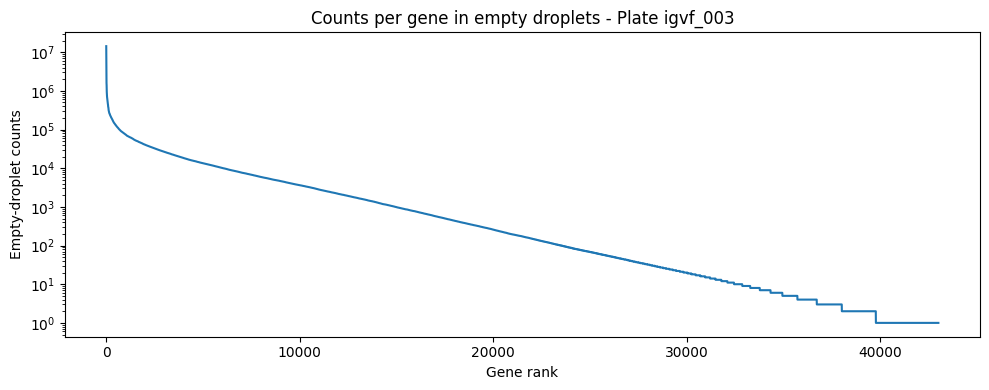

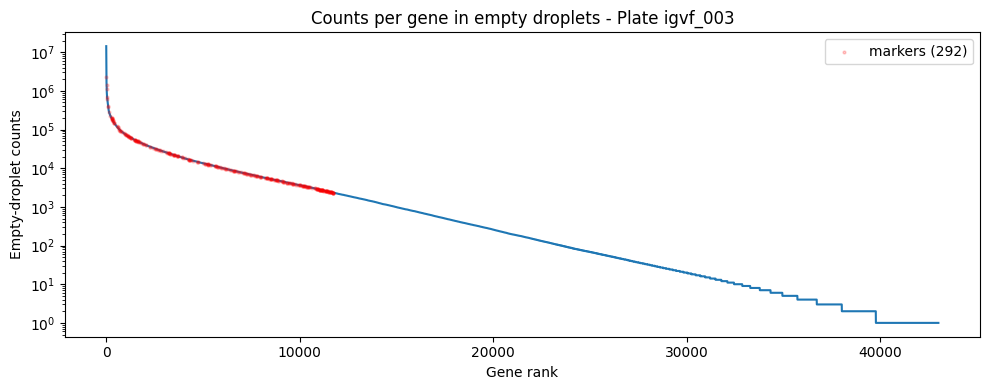

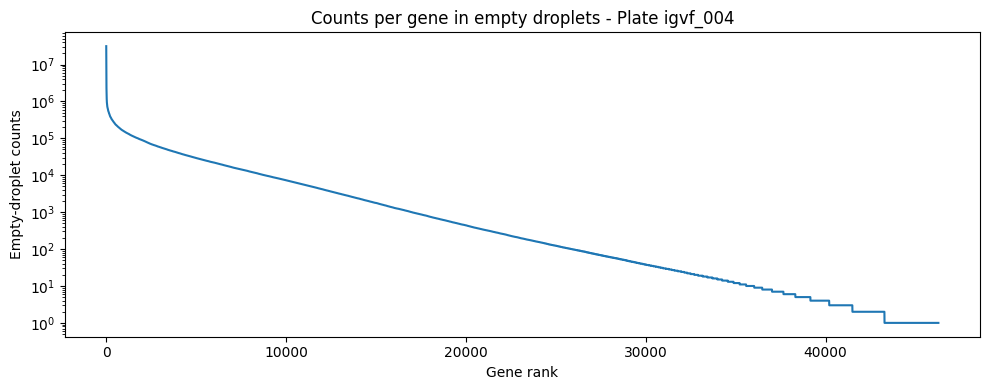

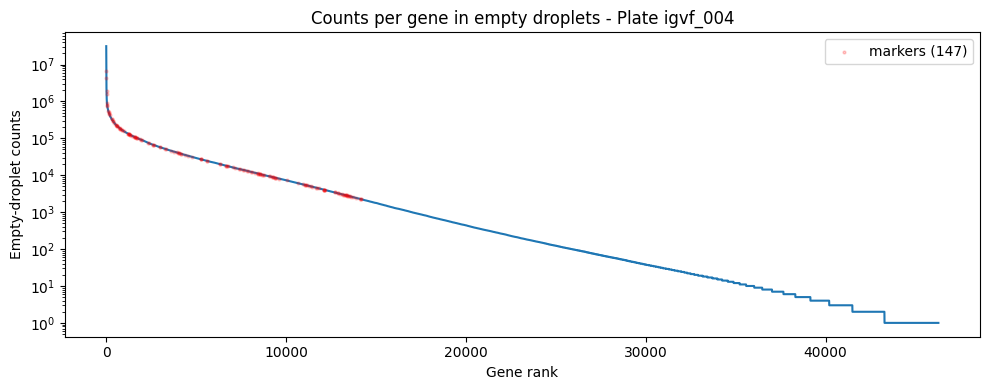

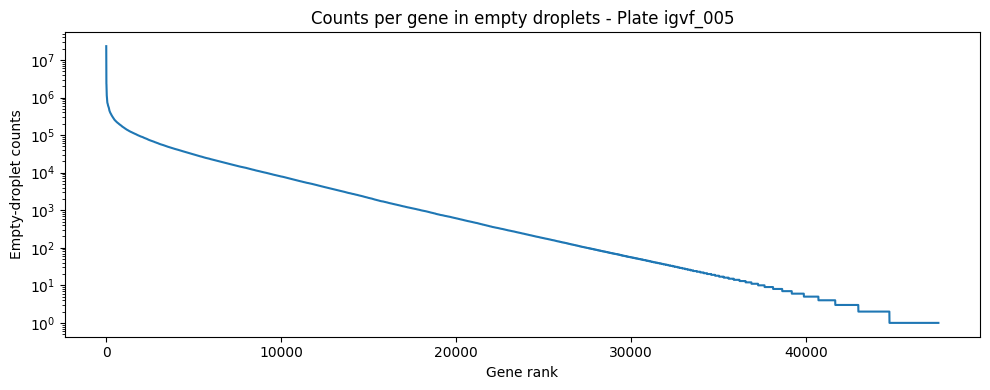

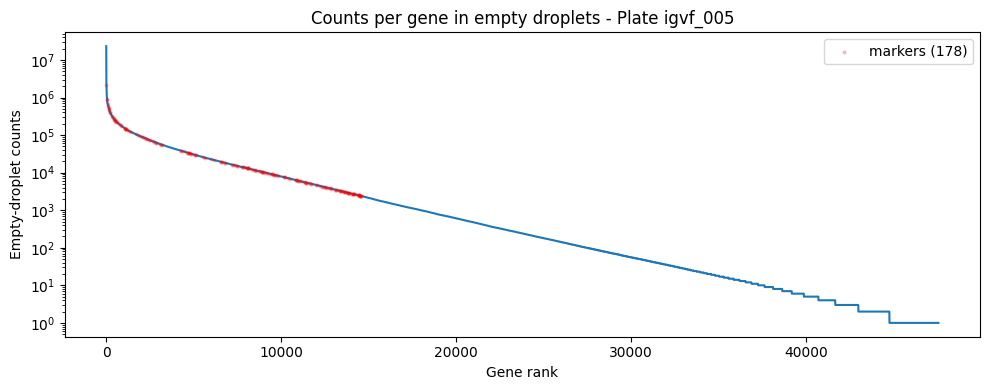

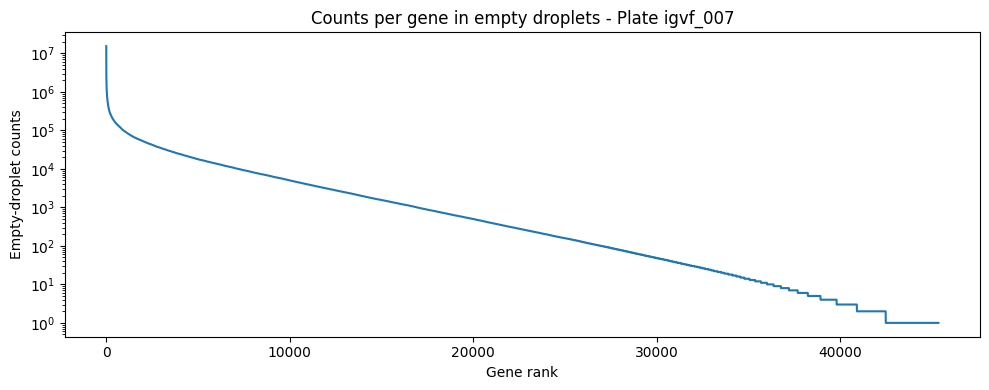

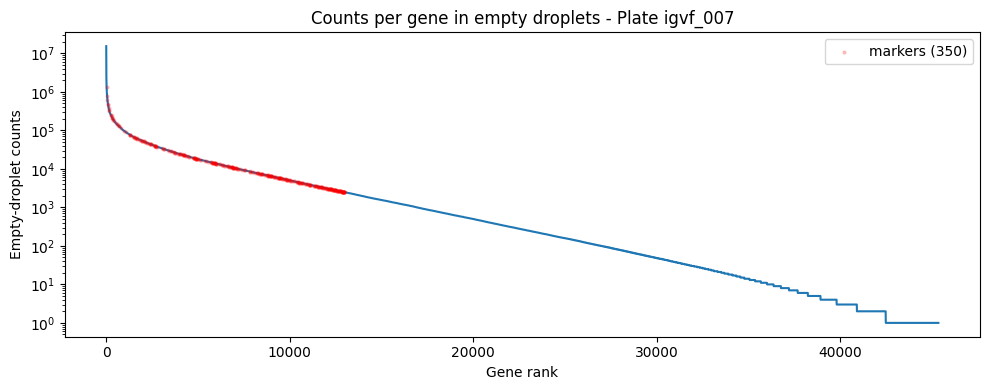

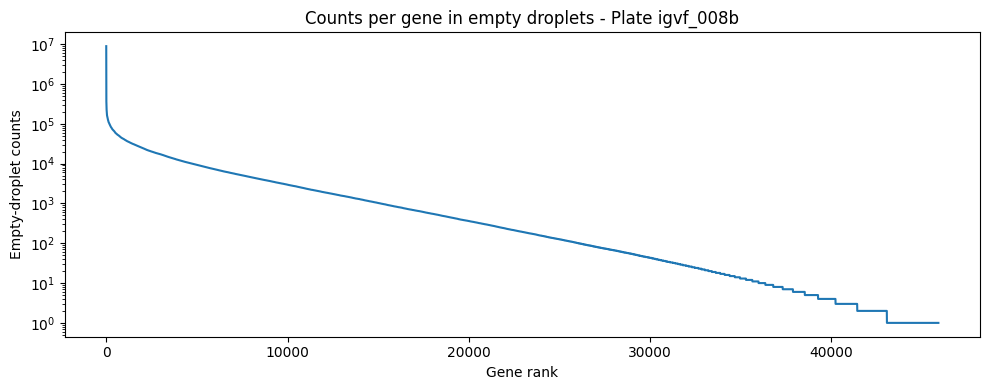

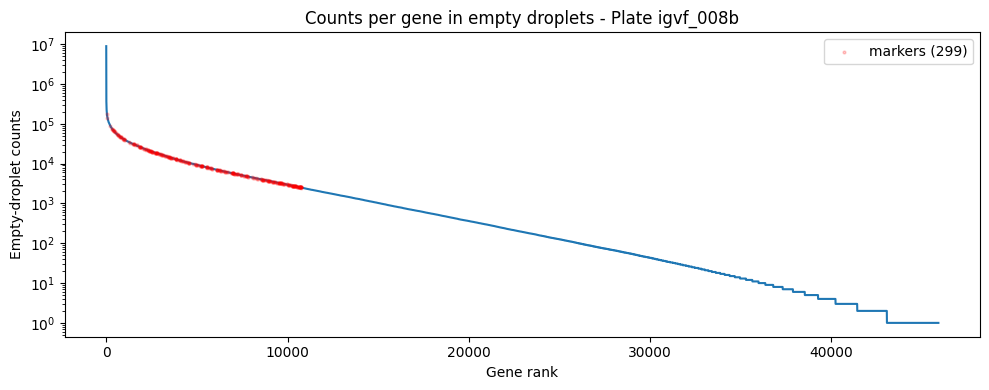

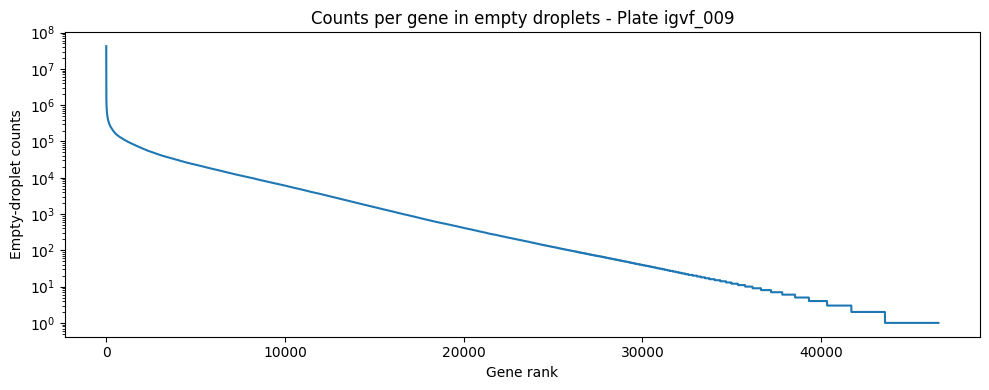

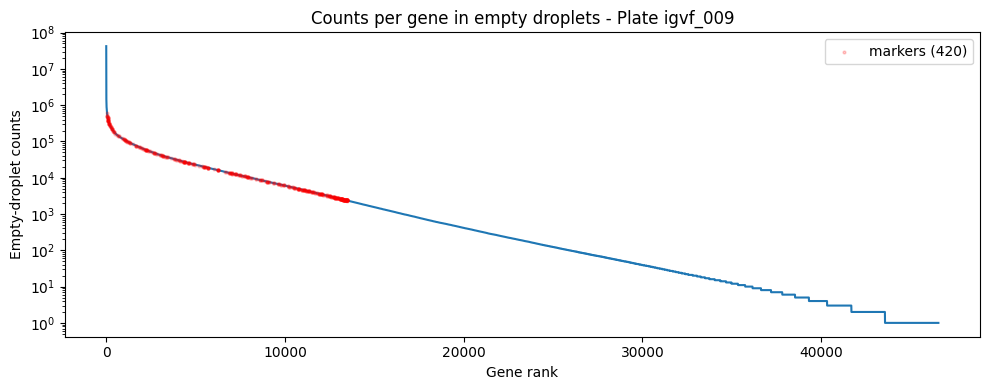

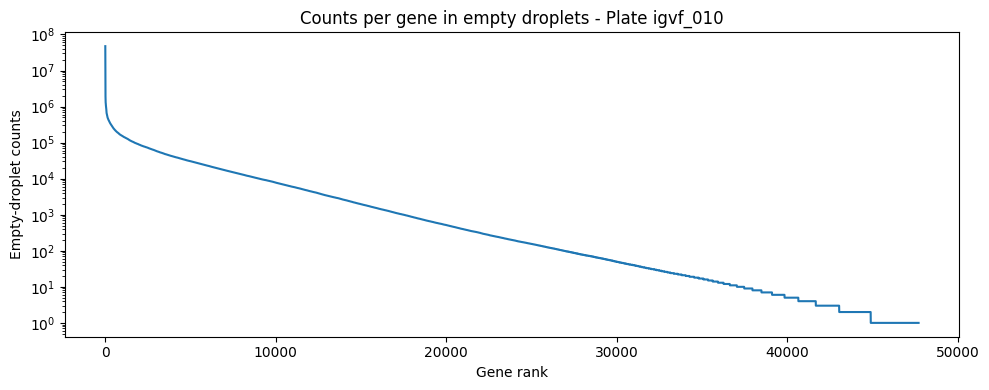

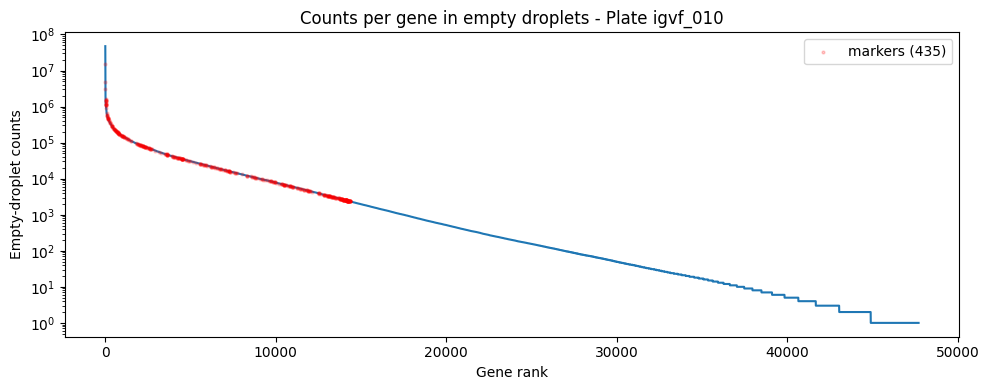

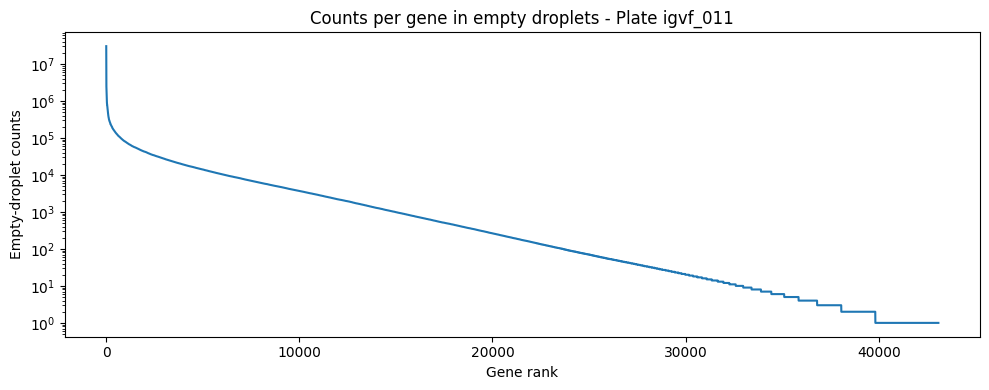

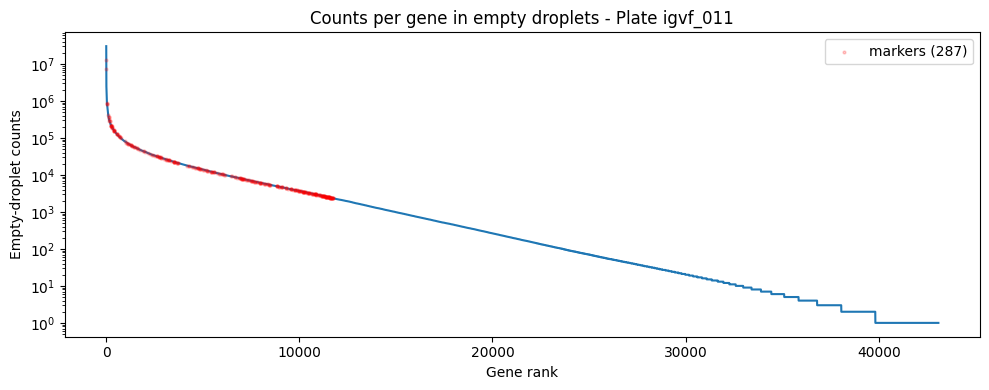

In [ ]:
import anndata as ad
import os
import pandas as pd
import cellsweep.utils as cs_utils
cellsweep_dir = os.path.dirname(os.path.abspath(""))
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", "8cubed")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "8cubed")
eight_cubed_markers_path = os.path.join(data_dir, "8_cube_marker_genes.csv")

eight_cubed_markers_df = pd.read_csv(eight_cubed_markers_path, usecols=["gene_id", "gene_name", "Tissue"])
eight_cubed_markers_df["Tissue"] = eight_cubed_markers_df["Tissue"].replace({
    "GonadsMale": "Gonads",
    "GonadsFemale": "Gonads",
})

plates = ["igvf_003", "igvf_004", "igvf_005", "igvf_007", "igvf_008b", "igvf_009", "igvf_010", "igvf_011"]
for plate in plates:
    print(f"Plate {plate}")
    adata_cellsweep = ad.read_h5ad(os.path.join(data_dir, plate, "cellsweep.h5ad"), backed="r")
    # adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()

    # plot ambient genes predicted
    cs_utils.plot_empty_gene_counts(adata_cellsweep, title=f"Counts per gene in empty droplets - Plate {plate}", highlight_indices=None, out_path=os.path.join(out_dir, f"empty_gene_counts_plate_{plate}.png"), show=True)

    # look at the "true" ambient genes (ie the marker genes for the incorrect tissues)
    tissues = adata_cellsweep.obs["Tissue"].unique().tolist()
    if len(tissues) != 2:
        print(f"Warning: Plate {plate} does not have exactly 2 tissues in adata_cellsweep. Found tissues: {tissues}. Skipping.")
        continue

    eight_cubed_markers_df_filtered = eight_cubed_markers_df[eight_cubed_markers_df["Tissue"].isin(tissues)]

    adata_cellsweep.var["ambient_rank"] = adata_cellsweep.var["ambient_hat"].rank(ascending=False, method="dense")

    ambient_df = adata_cellsweep.var[["ambient_hat", "ambient_rank"]].copy()
    eight_cubed_markers_df_filtered = eight_cubed_markers_df_filtered.merge(ambient_df, on="gene_id", how="left")
    eight_cubed_markers_df_filtered["ambient_rank"] = eight_cubed_markers_df_filtered["ambient_rank"].astype("Int64")

    eight_cubed_markers_df_filtered = eight_cubed_markers_df_filtered.sort_values(by="ambient_rank", ascending=True)
    eight_cubed_markers_df_filtered = eight_cubed_markers_df_filtered[~eight_cubed_markers_df_filtered["ambient_rank"].isna()]

    # plot ambient genes predicted
    cs_utils.plot_empty_gene_counts(adata_cellsweep, title=f"Counts per gene in empty droplets - Plate {plate}", highlight_indices=eight_cubed_markers_df_filtered["ambient_rank"], out_path=os.path.join(out_dir, f"empty_gene_counts_plate_{plate}_with_overlay.png"), show=True)
    
    # print eight_cubed_markers_df_filtered sorted ascending by ambient_rank
    with pd.option_context(
        "display.max_rows", 500,
        "display.max_columns", None,
        "display.width", 10_000,       # huge width prevents line breaks
        "display.max_colwidth", None  # prevents truncation
    ):
        print(eight_cubed_markers_df_filtered.head(500))
    
    print("--------------------------------\n")

    # break

## Trem2

In [5]:
adata_raw_trem2_dir = "/mnt/data1/8_cube_trem2_raw"
adata_filtered_trem2_dir = "/mnt/data1/8_cube_trem2_filtered"

In [ ]:
# !cd {adata_raw_trem2_dir} && curl -L -o sublibrary_67C.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI7692WGUI/@@download/IGVFFI7692WGUI.h5ad" && curl -L -o sublibrary_67D.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI1306QBMO/@@download/IGVFFI1306QBMO.h5ad" && curl -L -o sublibrary_67E.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI6709CSRA/@@download/IGVFFI6709CSRA.h5ad" && curl -L -o sublibrary_67F.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI7088RATR/@@download/IGVFFI7088RATR.h5ad"
# !cd {adata_filtered_trem2_dir} && curl -L -o CortexHippocampus_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI9921ZFSR/@@download/IGVFFI9921ZFSR.h5ad" && curl -L -o Heart_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI5206ZCKM/@@download/IGVFFI5206ZCKM.h5ad" && curl -L -o Liver_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI1208NQXL/@@download/IGVFFI1208NQXL.h5ad" && curl -L -o HypothalamusPituitary_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI3003LKFU/@@download/IGVFFI3003LKFU.h5ad" && curl -L -o Adrenal_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI5575XEVE/@@download/IGVFFI5575XEVE.h5ad" && curl -L -o Kidney_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI2996KNFS/@@download/IGVFFI2996KNFS.h5ad" && curl -L -o Gastrocnemius_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI9737TFCW/@@download/IGVFFI9737TFCW.h5ad" && curl -L -o GonadsMale_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI3964ARZC/@@download/IGVFFI3964ARZC.h5ad" && curl -L -o GonadsFemale_annotated.h5ad "https://api.data.igvf.org/matrix-files/IGVFFI5762MYZF/@@download/IGVFFI5762MYZF.h5ad"

In [6]:
gene_id_to_name = pd.read_csv(gene_id_name_map_path).set_index("gene_id")["gene_name"].to_dict()

### Load in

In [7]:
adata_raw_trem2_list = []
files = sorted([os.path.join(adata_raw_trem2_dir, f) for f in os.listdir(adata_raw_trem2_dir) if f.endswith(".h5ad")])
for filename in files:
    print(f"Loading {filename}...")
    sublibrary = os.path.basename(filename).replace(".h5ad", "")
    adata = ad.read_h5ad(filename, backed=None)
    adata.obs["sublibrary"] = sublibrary
    adata_raw_trem2_list.append(adata)
# concatenate
adata_raw_trem2 = ad.concat(adata_raw_trem2_list, join="outer")
adata_raw_trem2.obs[["barcode", "sample"]] = adata_raw_trem2.obs.index.to_series().str.rsplit("_", n=1, expand=True)
adata_raw_trem2.var["gene_name"] = adata_raw_trem2.var_names.map(gene_id_to_name)
# adata_raw_trem2.obs["sublibrary"] = adata_raw_trem2.obs["sublibrary"].astype("category")  # gives error
adata_raw_trem2

Loading /mnt/data1/8_cube_trem2_raw/sublibrary_67C.h5ad...
Loading /mnt/data1/8_cube_trem2_raw/sublibrary_67D.h5ad...
Loading /mnt/data1/8_cube_trem2_raw/sublibrary_67E.h5ad...
Loading /mnt/data1/8_cube_trem2_raw/sublibrary_67F.h5ad...


AnnData object with n_obs × n_vars = 3538156 × 78298
    obs: 'sublibrary', 'barcode', 'sample'
    var: 'gene_name'
    layers: 'ambiguous', 'mature', 'nascent'

### Merge in tissue data

In [ ]:
files = sorted([os.path.join(adata_filtered_trem2_dir, f) for f in os.listdir(adata_filtered_trem2_dir) if f.endswith(".h5ad")])
cols_to_merge = ["Tissue", "celltype", "leiden"]
for filename in files:
    tissue = os.path.basename(filename).replace("_annotated.h5ad", "")
    adata = ad.read_h5ad(filename, backed="r")
    print(f"Number of cells in filtered annotated tissue {tissue}: {adata.n_obs}")
    
    #!!!! I need to use additional information to map back to raw data barcodes since barcodes may be duplicated across tissues
    
    lookup = (
        adata.obs[["bc"] + cols_to_merge]
        .dropna(subset=["bc"])
        .drop_duplicates(subset=["bc"])
        .set_index("bc")
    )

    mapped = lookup.reindex(adata_raw_trem2.obs["barcode"])
    mask = mapped.notna().any(axis=1).to_numpy()
    adata_raw_trem2.obs.loc[mask, cols_to_merge] = mapped.loc[mask, cols_to_merge].values

    adata_raw_trem2.obs["tissue_specific_celltype"] = adata_raw_trem2.obs["celltype"]
    adata_raw_trem2.obs["celltype"] = adata_raw_trem2.obs["Tissue"] + "_" + adata_raw_trem2.obs["celltype"].fillna("empty")

Loading /mnt/data1/8_cube_trem2_filtered/Adrenal_annotated.h5ad...
Loading /mnt/data1/8_cube_trem2_filtered/CortexHippocampus_annotated.h5ad...
Loading /mnt/data1/8_cube_trem2_filtered/Gastrocnemius_annotated.h5ad...
Loading /mnt/data1/8_cube_trem2_filtered/GonadsFemale_annotated.h5ad...
Loading /mnt/data1/8_cube_trem2_filtered/GonadsMale_annotated.h5ad...
Loading /mnt/data1/8_cube_trem2_filtered/Heart_annotated.h5ad...
Loading /mnt/data1/8_cube_trem2_filtered/HypothalamusPituitary_annotated.h5ad...
Loading /mnt/data1/8_cube_trem2_filtered/Kidney_annotated.h5ad...
Loading /mnt/data1/8_cube_trem2_filtered/Liver_annotated.h5ad...


In [ ]:
# make sure Tissue count is not bigger than original file
adata_raw_trem2.obs["Tissue"].value_counts()

Tissue
DiencephalonPituitary    132968
CortexHippocampus        117620
Adrenal                   80960
Gastrocnemius             64795
Liver                     58108
Kidney                    51180
Heart                     38147
GonadsFemale              34904
GonadsMale                25664
Name: count, dtype: int64

### Knee plot and empty inference

In [ ]:
print(f"Processing sublibrary {sublibrary} for knee plot...")
umi_cutoff = cs_utils.knee_plot(adata_raw_trem2)

In [ ]:
umi_cutoff = 500  #!! set from knee plot

In [ ]:
adata_raw_trem2 = cs_utils.infer_empty_droplets(adata_raw_trem2, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
adata_raw_trem2.var['empty_counts'] = np.array(adata_raw_trem2.X[adata_raw_trem2.obs['is_empty'].values, :].sum(axis=0)).flatten()

### save

In [ ]:
adata_path = os.path.join(data_dir, "trem2", "raw_counts.h5ad")
if not os.path.exists(adata_path):
    os.makedirs(os.path.dirname(adata_path), exist_ok=True)
    adata_raw_trem2.write_h5ad(adata_path)

### Run cellsweep

In [ ]:
adata_path_cellsweep_trem2 = os.path.join(data_dir, "trem2", "cellsweep.h5ad")
if not os.path.exists(adata_path_cellsweep_trem2) or overwrite:
    print(f"Processing Cellsweep trem2")
    # adata_raw = ad.read_h5ad(os.path.join(data_dir, plate, "raw_counts.h5ad"))
    cellsweep_log_path = os.path.join(data_dir, "trem2", "cellsweep.log")
    adata_cellsweep_trem2 = denoise_count_matrix(adata_raw, adata_out=adata_path_cellsweep_trem2, beta=cellsweep_beta, freeze_ambient_profile=True, init_alpha=cellsweep_init_alpha, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells[plate], threads=threads, verbose=verbose, log_file=cellsweep_log_path)
else:
    print(f"Cellsweep output for trem2 already exists at {adata_path_cellsweep_trem2}, skipping...")

<Figure size 1000x400 with 0 Axes>

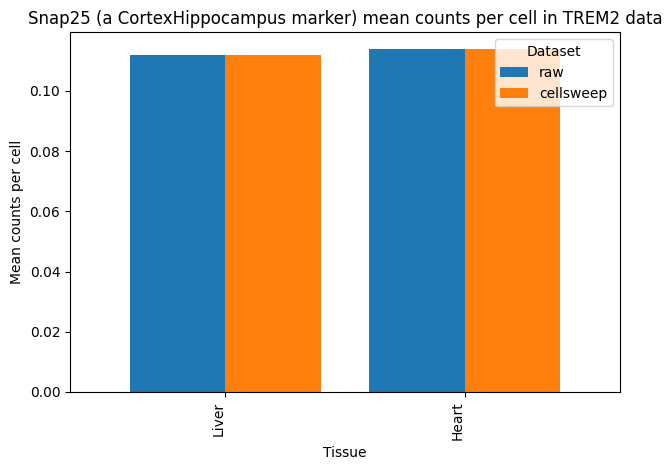

<Figure size 1000x400 with 0 Axes>

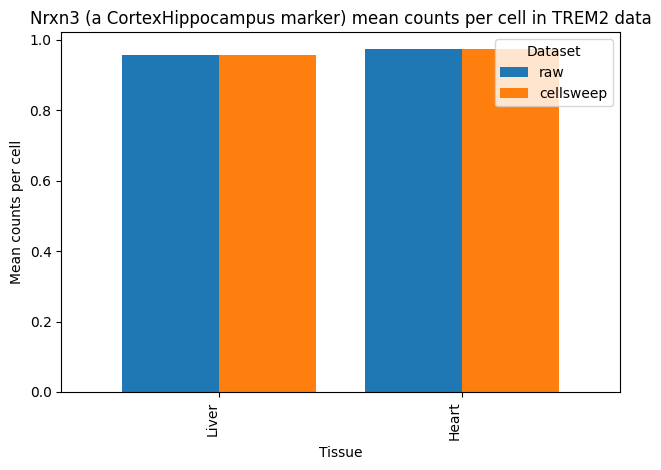

<Figure size 1000x400 with 0 Axes>

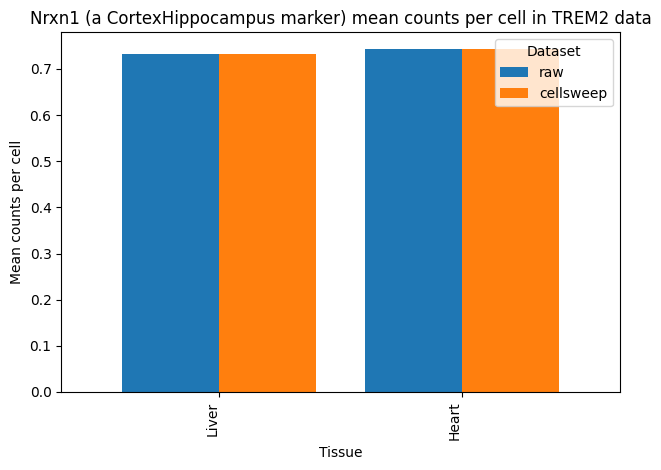

<Figure size 1000x400 with 0 Axes>

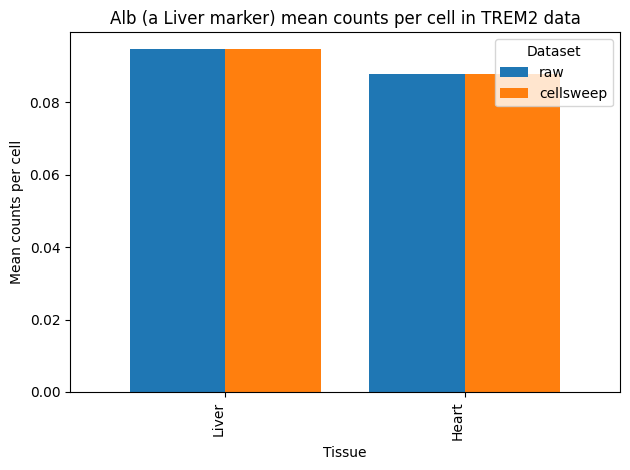

<Figure size 1000x400 with 0 Axes>

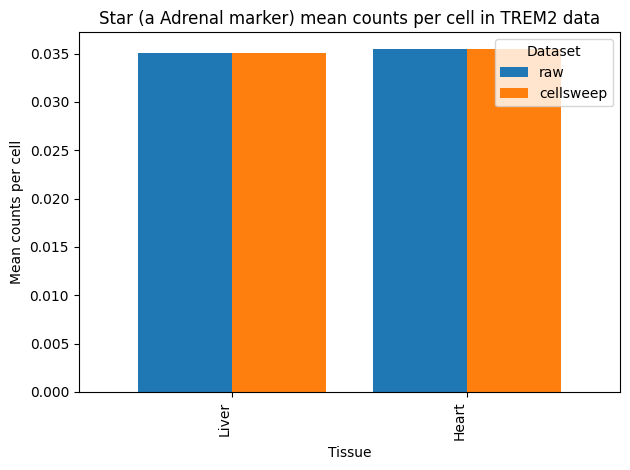

<Figure size 1000x400 with 0 Axes>

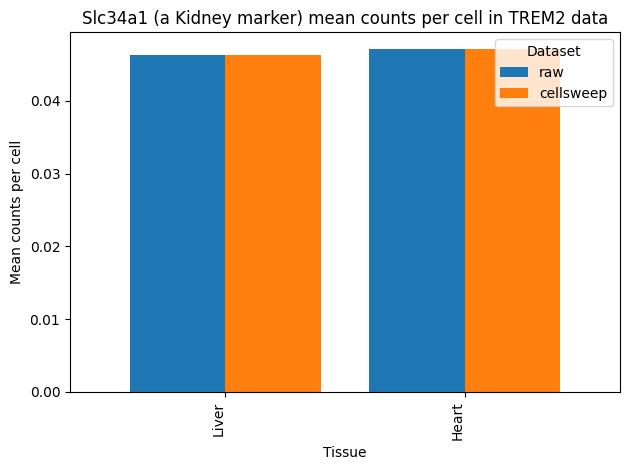

<Figure size 1000x400 with 0 Axes>

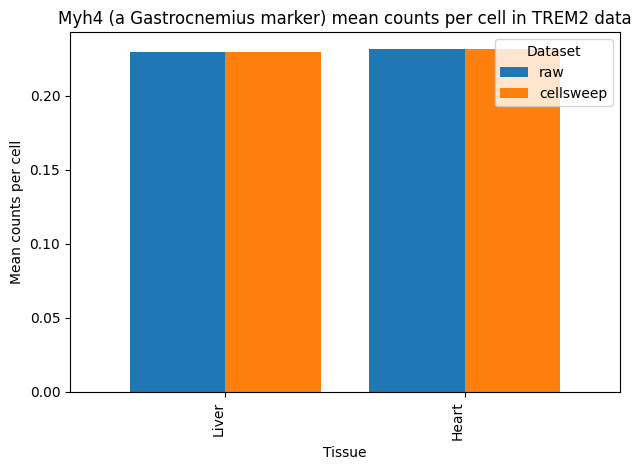

<Figure size 1000x400 with 0 Axes>

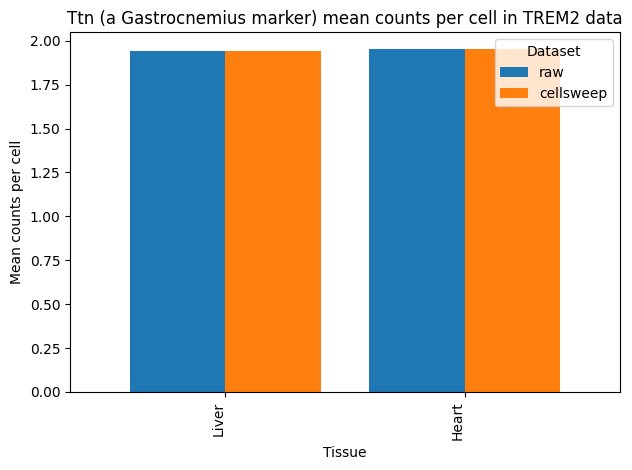

<Figure size 1000x400 with 0 Axes>

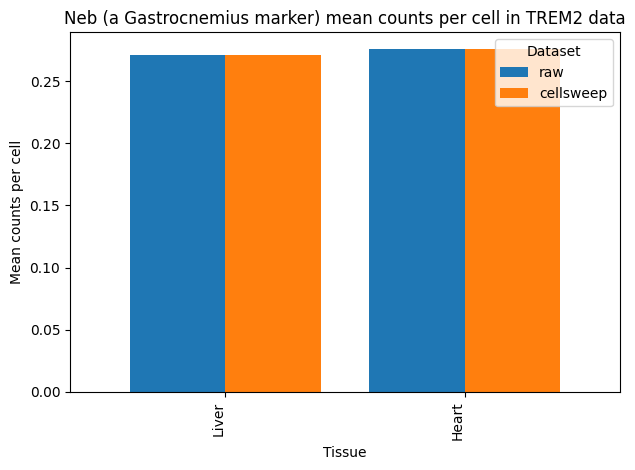

<Figure size 1000x400 with 0 Axes>

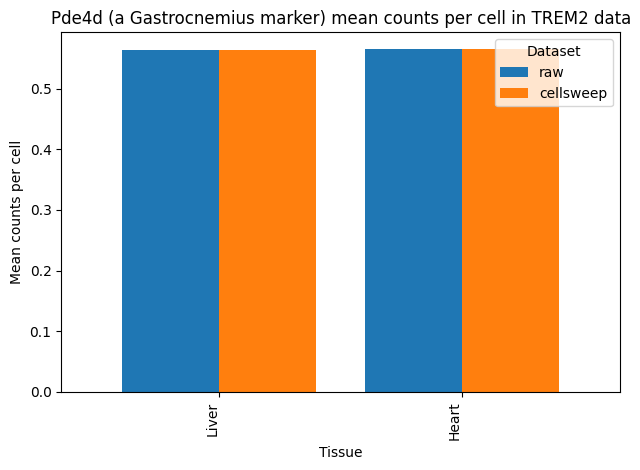

<Figure size 1000x400 with 0 Axes>

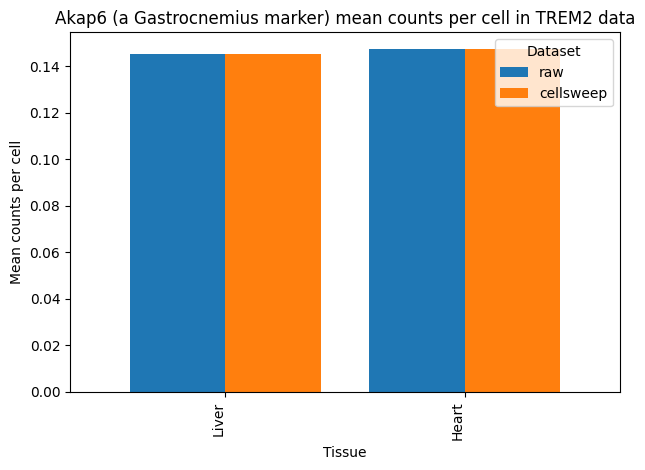

In [8]:
# for debugging
# np.random.seed(42)
# adata_raw_trem2.obs["Tissue"] = np.random.choice(["Liver", "Heart"], size=adata_raw_trem2.n_obs)
# adata_cellsweep_trem2 = adata_raw_trem2.copy()

custom_markers = {
    'CortexHippocampus': ["Snap25", "Nrxn3", "Nrxn1"],
    'Heart': [],
    'Liver': ["Alb"],
    'HypothalamusPituitary': [],
    'Gonads': [],
    'Adrenal': ["Star"],
    'Kidney': ["Slc34a1"],
    'Gastrocnemius': ["Myh4", "Ttn", "Neb", "Pde4d", "Akap6"]
}

# keep only genes that exist
for gene_tissue, genes in custom_markers.items():
    for gene in genes:
        series_list = []
        for adata_name, adata_object in {"raw": adata_raw_trem2, "cellsweep": adata_cellsweep_trem2}.items():
            if adata_object is None:
                continue

            if gene not in adata_object.var["gene_name"].values:
                print(f"Warning: Gene {gene} not found in adata object var.")
                continue
            
            gi = adata_object.var["gene_name"].astype(str).tolist().index(gene)
            
            counts = {}
            tissues = adata_object.obs["Tissue"].dropna().unique().tolist()
            
            for tissue in tissues:
                mask = adata_object.obs["Tissue"] == tissue
                X_sub = adata_object[mask, gi].X  # column slice → (cells × 1)

                total = X_sub.sum() if sp.issparse(X_sub) else np.sum(X_sub)
                counts[tissue] = float(total) / mask.sum()

            s = pd.Series(counts, name=adata_name)
            series_list.append(s)

        if len(series_list) == 0:
            continue
        
        df = pd.concat(series_list, axis=1).fillna(0)

        plt.figure(figsize=(10, 4))
        df.plot(kind="bar", width=0.8)
        plt.ylabel("Mean counts per cell")
        plt.xlabel("Tissue")
        plt.title(f"{gene} (a {gene_tissue} marker) mean counts per cell in TREM2 data")
        plt.xticks(rotation=90, ha="right")
        plt.legend(title="Dataset")
        plt.tight_layout()

        out_path = os.path.join(out_dir, "trem2", f"{gene}_counts_per_tissue_trem2.png")
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        plt.savefig(out_path, dpi=300)

        plt.show()